# Assignment 4 — How Few Components Can You Get Away With?

**Course:** Feature Engineering & MLOps  
**Assignment No.:** 4  
**Topic:** PCA — Explained Variance, Scree Plot, Choosing the Optimal Number of Components  
**Student:** Shikha Omkar Singh

## Objective
Find the **smallest number of principal components** that allows a Linear Regression model to achieve roughly the same test $R^2$ as a model trained using all 60 raw features.

**Reproducibility:** `random_state=42` is used for the train/test split and models where applicable.

## Dataset

The assignment specification says that `data/raw/pca_regression_data.csv` contains **800 rows, 60 numeric features (`feature_1` ... `feature_60`) and a continuous target `score`**.

The supplied CSV also contains `student_id`. This is an identifier, not one of the 60 modeling features, so it is excluded from `X`.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 10)
pd.set_option("display.precision", 6)

In [5]:
DATA_PATH = "data/raw/pca_regression_data.csv"

df = pd.read_csv("/Users/shikhasingh/Downloads/Assignment4_PCA_Components/data/raw/pca_regression_data.csv")

feature_names = [f"feature_{i}" for i in range(1, 61)]
target_name = "score"

print(f"Dataset shape: {df.shape}")
print(f"Number of required features: {len(feature_names)}")
print(f"Target column: {target_name}")
print(f"Missing values in required columns: {int(df[feature_names + [target_name]].isna().sum().sum())}")

display(df[feature_names + [target_name]].head())

Dataset shape: (800, 62)
Number of required features: 60
Target column: score
Missing values in required columns: 0


,feature_1,feature_2,feature_3,feature_4,feature_5,...,feature_57,feature_58,feature_59,feature_60,score
0,1.006103,2.625090,-0.021036,6.231392,3.147998,...,-0.345406,3.255827,0.607355,1.126482,-0.319225
1,4.442871,-2.006560,-1.181818,1.695413,-3.168459,...,0.681762,-4.742943,2.150911,-5.587529,3.418536
2,1.723720,-3.352754,1.020613,0.533918,3.769766,...,3.324718,-1.858829,2.980939,1.121997,2.618471
3,0.411140,2.025221,-2.621914,-5.890728,-1.068567,...,1.066226,2.996332,4.766362,1.312600,-3.740992
4,1.011855,3.029584,-2.574027,-1.983156,-1.696483,...,-2.490620,1.414216,-1.392051,0.611356,1.294747


## 4.1 — Baseline: all 60 raw features

1. Split the dataset into **75% train and 25% test** with a fixed random state.
2. Standardize the 60 features using the training set only.
3. Train Linear Regression on all 60 standardized features.
4. Report test $R^2$.

In [6]:
X = df[feature_names]
y = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Training feature matrix: {X_train_scaled.shape}")
print(f"Test feature matrix: {X_test_scaled.shape}")

Training rows: 600
Test rows: 200
Training feature matrix: (600, 60)
Test feature matrix: (200, 60)


In [7]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline test R² (60 standardized features): {baseline_r2:.6f}")

Baseline test R² (60 standardized features): 0.858373


## 4.2 — PCA: explained variance and the scree plot

PCA is fitted **only on the standardized training features**. The scree plot below shows the explained variance ratio for at least the first 20 principal components.

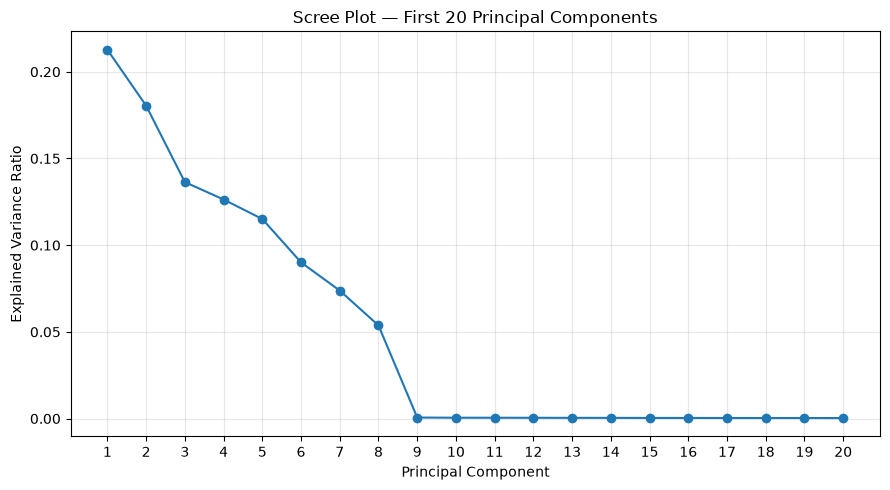

In [8]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

n_plot = 20
components = np.arange(1, n_plot + 1)

plt.figure(figsize=(9, 5))
plt.plot(components, explained_variance_ratio[:n_plot], marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot — First 20 Principal Components")
plt.xticks(components)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visual elbow estimate — BEFORE model comparison

From the scree plot alone, the curve drops steeply through the first several components and becomes much flatter after about **8 components**. Therefore, my visual elbow estimate is **approximately 8 components**.

This is a visual estimate only; the final choice is determined using held-out test $R^2$.

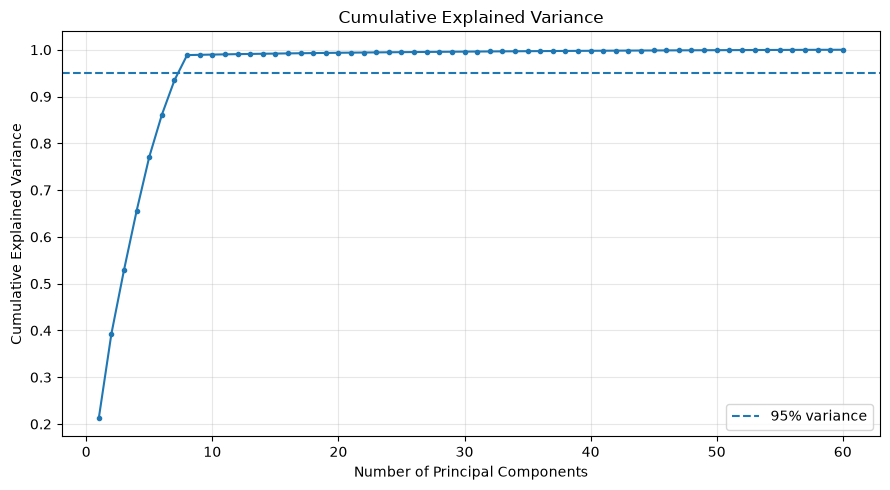

Smallest number of components reaching at least 95% cumulative variance: 8


In [9]:
plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker="o",
    markersize=3
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

first_95 = int(np.argmax(cumulative_explained_variance >= 0.95) + 1)
print(f"Smallest number of components reaching at least 95% cumulative variance: {first_95}")

In [10]:
variance_summary = pd.DataFrame({
    "component": np.arange(1, 21),
    "explained_variance_ratio": explained_variance_ratio[:20],
    "cumulative_explained_variance": cumulative_explained_variance[:20]
})
display(variance_summary)

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.212700,0.212700
1,2,0.180426,0.393125
2,3,0.136387,0.529512
3,4,0.126337,0.655849
4,5,0.115100,0.770949
5,6,0.090079,0.861028
6,7,0.073817,0.934845
7,8,0.053718,0.988563
8,9,0.000605,0.989168
9,10,0.000504,0.989672


## 4.3 — Find the smallest component count that matches baseline accuracy

Required component counts:

`[2, 4, 6, 8, 10, 12, 15, 20, 30, 40]`

For each count, PCA is fitted on the standardized training data, train/test data are transformed, and a fresh Linear Regression model is trained.

**Selection rule:** choose the smallest tested count whose test $R^2$ is within **0.01 of the baseline**, or exceeds the baseline.

In [11]:
component_counts = [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]

results = []

for n_components in component_counts:
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)

    test_r2 = r2_score(y_test, model.predict(X_test_pca))

    results.append({
        "components": n_components,
        "cumulative_explained_variance": pca.explained_variance_ratio_.sum(),
        "test_R2": test_r2,
        "difference_from_baseline": test_r2 - baseline_r2,
        "within_0.01_of_baseline": test_r2 >= baseline_r2 - 0.01
    })

results_df = pd.DataFrame(results)
display(results_df)

,components,cumulative_explained_variance,test_R2,difference_from_baseline,within_0.01_of_baseline
0,2,0.393125,0.240924,-0.617449,False
1,4,0.655849,0.498896,-0.359477,False
2,6,0.861028,0.694589,-0.163784,False
3,8,0.988563,0.871584,0.013211,True
4,10,0.989672,0.872236,0.013863,True
5,12,0.990620,0.871817,0.013444,True
6,15,0.991831,0.872381,0.014008,True
7,20,0.993511,0.872546,0.014172,True
8,30,0.995970,0.866501,0.008128,True
9,40,0.997769,0.863369,0.004995,True


In [12]:
matching = results_df[results_df["within_0.01_of_baseline"]]

if matching.empty:
    smallest_matching_components = None
    print("None of the required component counts is within 0.01 of or above the baseline.")
else:
    smallest_matching_components = int(matching.iloc[0]["components"])
    selected_r2 = float(matching.iloc[0]["test_R2"])
    print(f"Baseline test R²: {baseline_r2:.6f}")
    print(f"Smallest matching component count: {smallest_matching_components}")
    print(f"Test R² at {smallest_matching_components} components: {selected_r2:.6f}")
    print(f"Difference from baseline: {selected_r2 - baseline_r2:+.6f}")

Baseline test R²: 0.858373
Smallest matching component count: 8
Test R² at 8 components: 0.871584
Difference from baseline: +0.013211


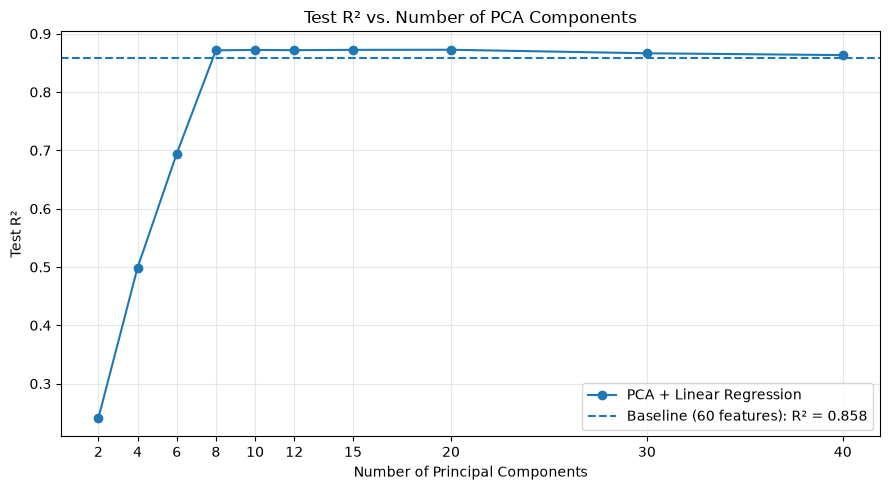

In [13]:
plt.figure(figsize=(9, 5))
plt.plot(
    results_df["components"],
    results_df["test_R2"],
    marker="o",
    label="PCA + Linear Regression"
)
plt.axhline(
    baseline_r2,
    linestyle="--",
    label=f"Baseline (60 features): R² = {baseline_r2:.3f}"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Test R²")
plt.title("Test R² vs. Number of PCA Components")
plt.xticks(component_counts)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Component-selection conclusion

The smallest tested component count that satisfies the assignment rule is **8 components**. Its test $R^2$ is higher than the all-60-feature baseline, so PCA slightly improves held-out performance while reducing the representation from 60 dimensions to 8.

The visual scree-plot elbow estimate was also **about 8 components**, so the visual and empirical selections agree.

## 4.4 — Explain it

The baseline Linear Regression using all 60 standardized features achieved a test $R^2$ of **0.858373**. Using only **8 principal components** produced a test $R^2$ of **0.871584**, which is about **0.013211 higher** than the baseline and therefore satisfies the required 0.01 criterion. The first 8 components explain about **98.856%** of the training-set variance, while the remaining components contribute only small amounts of additional variance individually. This indicates that many of the original 60 features contain redundant or correlated information that can be represented by a much smaller set of underlying directions. PCA can therefore remove low-variance directions and reduce multicollinearity/noise, which can help Linear Regression generalize slightly better on the held-out test set. The scree-plot elbow and accuracy-based selection both point to about 8 components, providing consistent evidence for the dataset's effective lower-dimensional structure.

## Final Answer

**How few components can you get away with? → 8 principal components.**

| Measure | Result |
|---|---:|
| Baseline features | 60 |
| Baseline test R² | 0.858373 |
| Selected PCA components | **8** |
| Test R² with 8 components | **0.871584** |
| Difference from baseline | **+0.013211** |
| Variance explained by first 8 PCs | **98.8563%** |
| Visual scree-plot elbow | **~8 components** |
| 95% cumulative variance reached at | **8 components** |

# Bonus (+10%) — RandomForestRegressor

Repeat the component comparison with a tree-based model. `random_state=42` and `n_estimators=300` are used for reproducibility.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_baseline = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_r2 = r2_score(y_test, rf_baseline.predict(X_test_scaled))

rf_results = []

for n_components in component_counts:
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_model.fit(X_train_pca, y_train)

    rf_test_r2 = r2_score(y_test, rf_model.predict(X_test_pca))

    rf_results.append({
        "components": n_components,
        "test_R2": rf_test_r2,
        "difference_from_rf_baseline": rf_test_r2 - rf_baseline_r2,
        "within_0.01_of_rf_baseline": rf_test_r2 >= rf_baseline_r2 - 0.01
    })

rf_results_df = pd.DataFrame(rf_results)

print(f"Random Forest baseline test R²: {rf_baseline_r2:.6f}")
display(rf_results_df)

Random Forest baseline test R²: 0.800846


,components,test_R2,difference_from_rf_baseline,within_0.01_of_rf_baseline
0,2,0.164529,-0.636317,False
1,4,0.418786,-0.382060,False
2,6,0.607113,-0.193733,False
3,8,0.742536,-0.058310,False
4,10,0.732142,-0.068704,False
5,12,0.724917,-0.075929,False
6,15,0.715450,-0.085396,False
7,20,0.703349,-0.097497,False
8,30,0.684529,-0.116317,False
9,40,0.667006,-0.133840,False


None of the required PCA component counts matched the Random Forest baseline within 0.01.


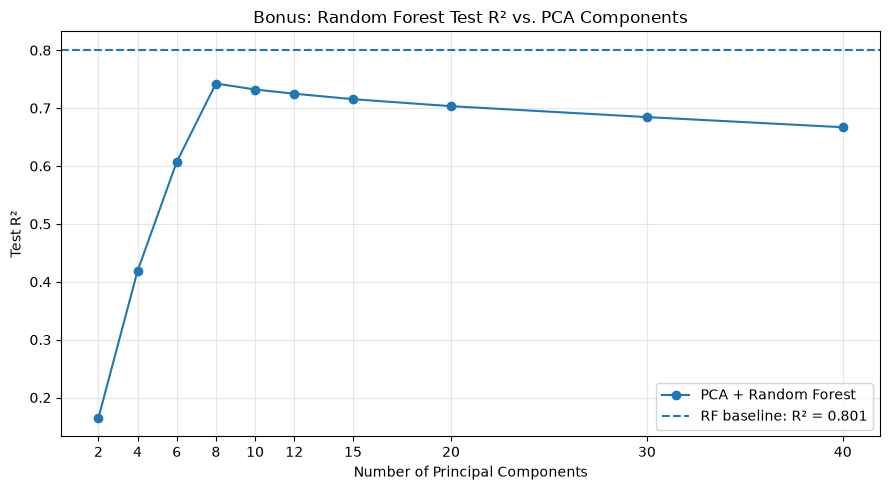

In [15]:
rf_matching = rf_results_df[rf_results_df["within_0.01_of_rf_baseline"]]

if rf_matching.empty:
    print("None of the required PCA component counts matched the Random Forest baseline within 0.01.")
else:
    print("Smallest matching component count:", int(rf_matching.iloc[0]["components"]))

plt.figure(figsize=(9, 5))
plt.plot(
    rf_results_df["components"],
    rf_results_df["test_R2"],
    marker="o",
    label="PCA + Random Forest"
)
plt.axhline(
    rf_baseline_r2,
    linestyle="--",
    label=f"RF baseline: R² = {rf_baseline_r2:.3f}"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Test R²")
plt.title("Bonus: Random Forest Test R² vs. PCA Components")
plt.xticks(component_counts)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Bonus explanation

The Random Forest does **not** reach its full-feature baseline within 0.01 for any of the required component counts tested. This differs from Linear Regression because PCA creates rotated linear combinations of the original features, while tree-based models make split decisions along individual feature axes. That rotation can make useful information harder for axis-aligned tree splits to exploit efficiently, even when PCA retains most of the total variance. In this dataset, the linear model benefits substantially from the 8-component representation, whereas the Random Forest loses predictive performance after PCA. This shows that dimensionality reduction should be evaluated with the actual downstream model rather than assuming that the same component count will work for every model.

## Reproducibility and submission checklist

- [x] Dataset loaded from `data/raw/pca_regression_data.csv`
- [x] 75/25 train-test split with fixed `random_state=42`
- [x] StandardScaler fitted on training data only
- [x] Linear Regression baseline using all 60 standardized features
- [x] Scree plot for first 20 components
- [x] Separate cumulative explained variance plot with 95% reference line
- [x] Visual elbow estimate recorded before model comparison
- [x] All required component counts tested
- [x] Test R² comparison chart with baseline reference
- [x] Smallest component count identified using the 0.01 rule
- [x] Section 4.4 explanation included
- [x] Optional RandomForestRegressor bonus included